In [24]:
X = [1,2,3,10]
Y = [10, 20, 30, 40]

Z = zip(X,Y)
X_plus_Y = []

for x, y in Z:
    X_plus_Y.append(x+y)

print("Z = X + Y =", X_plus_Y)

Z = [x+y for x, y in zip(X,Y)]
print("Z =", Z)

def added(X, Y):
    return X+Y
    
addition = map(added, X, Y)

print("addition", list(addition))

Z = X + Y = [11, 22, 33, 50]
Z = [11, 22, 33, 50]
addition [11, 22, 33, 50]


In [2]:
import numpy as np

# First user inputs R for rock, P for paper, S for scissors

user = input("User choice (R, P, S): ").upper()

# Then the computer will answer R, P, or S at random in response

options = np.array(['R', 'P', 'S'])                 # Computer can choose between R for rock, P for paper, and S for scissors
indx = np.random.randint(0, len(options))           # Answers 1 of the 3 options per game
computer = options[indx]                            # Computer's output

print("Computer choice:", computer)                 # Computer will print R or P or S at random

# Judge the result: who wins, who loses, and if there is a tie

if user == computer:
    print("Tie")
    
elif (user == 'R' and computer == 'S') or (user == 'P' and computer == 'R') or (user == 'S' and computer == 'P'):
    print("User wins")

else:
    print("Computer wins")

User choice (R, P, S):  P


Computer choice: R
User wins


Calculated mean = 185.010 cm
Calculated std = 8.007 cm


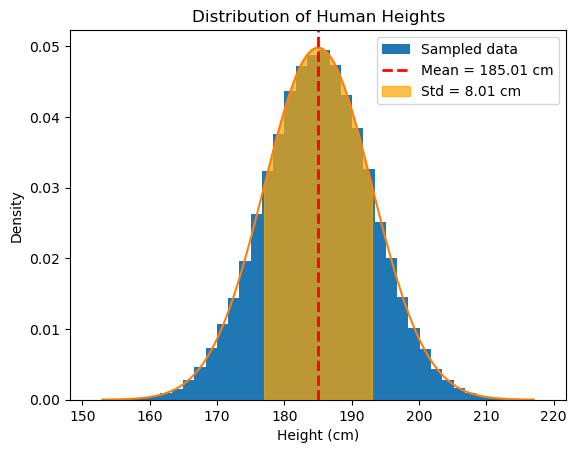

P(X <= h) = 0.9694
P(mean - std <= X <= mean + std) = 0.6827


In [13]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt 

lengths = np.random.normal(185, 8, 100000)

Mean = np.mean(lengths)
Std = np.std(lengths)

print(f"Calculated mean = {Mean:.3f} cm")
print(f"Calculated std = {Std:.3f} cm")

fig, frame = plt.subplots(1, 1)                                     # fig: whole figure, frame: plotting area (axes)
frame.hist(lengths, bins=40, density=True, label='Sampled data')    # bins: divides data in 40 bars

x = np.linspace(Mean - 4*Std, Mean + 4*Std, 1000)         #Creates 1000 evenly spaced x-values, range: 4 std's below mean to 4 above
y = norm.pdf(x, loc=Mean, scale=Std)     # Normal probability density function at each x
frame.plot(x,y)

frame.axvline(Mean, color='red', linewidth=2, linestyle="--", label=f"Mean = {Mean:.2f} cm")

x_shade = np.linspace(Mean - Std, Mean + Std, 500)
y_shade = norm.pdf(x_shade, loc=Mean, scale=Std) 
frame.fill_between(x_shade, y_shade, color='orange', alpha=0.7, label=f"Std = {Std:.2f} cm")      # Fills area under curve

plt.xlabel("Height (cm)")
plt.ylabel("Density")
plt.title("Distribution of Human Heights")

plt.legend()
plt.show()

h = 200

P_200 = norm.cdf(h, Mean, Std)
P1 = norm.cdf(Mean+Std, Mean, Std) - norm.cdf(Mean-Std, Mean, Std)

print(f"P(X <= h) = {P_200:.4f}")
print(f"P(mean - std <= X <= mean + std) = {P1:.4f}")

In [48]:
import numpy as np
from numpy import cos, sin, tan, log, cosh, sinh, tanh

function = input("Enter a function f(x)=")

a = float(input("Enter lower bound a ="))
b = float(input("Enter upper bound b ="))
N = int(input("Enter number of random points ="))

x = np.random.uniform(a,b,N)

f = eval(function)

integral = (b-a) * (1/N) * np.mean(f)

print(f"Result of integral: {integral:.6f}")

Enter a function f(x)= cos(x)
Enter lower bound a = 2
Enter upper bound b = 3
Enter number of random points = 100


Result of integral: -0.007517


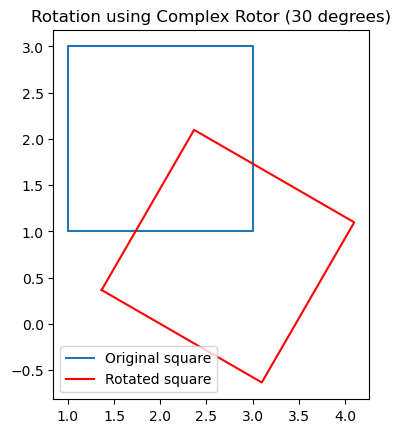

In [14]:
import numpy as np
import math      
import matplotlib.pyplot as plt 

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

angle_degs = -30      # Negative means clockwise rotation
theta = math.radians(angle_degs)

rotor = math.cos(theta) + 1j * math.sin(theta)   # Creates complex number
z = x + 1j * y          # Each point becomes a complex number
z_rot = rotor * z       # Multiplies every point by the rotor

x_rot = np.real(z_rot)
y_rot = np.imag(z_rot)

plt.plot(x, y, label="Original square")
plt.plot(x_rot, y_rot, color="red", label="Rotated square")

plt.gca().set_aspect('equal', adjustable='box')               # Equal: 1 unit on x-axis = 1 unit on y-axis
plt.title("Rotation using Complex Rotor (30 degrees)")

plt.legend()
plt.show()

In [6]:
import numpy as np

def funcfilter(func, seq):
    arr = np.asarray(seq)
    
    filtered = arr[arr > 0]
    
    result = func(filtered)
    
    return result

sq = np.array([-100, -10, 0, 10, 100])
result = funcfilter(np.log10, sq)
print("Result log10:", result)

result_single = funcfilter(np.log10, 100)
print("Result log10 (single number):", result_single)

Result log10: [1. 2.]
Result log10 (single sumber): [2.]


In [6]:
import numpy as np
from astropy.cosmology import Planck18
from scipy import integrate

H0 = Planck18.H0.value
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

Mpc_in_km = 3.086e19
H0_SI = H0/Mpc_in_km    # Converts Hubble constant from km/s/Mpc into 1/s

def H(z):
    y1 = H0_SI * np.sqrt(Om0 * (1+z)**3 + Ode0)
    return y1

def t(zp):
    y2 = 1/((1+zp)*H(zp))
    return y2

z = 2
t_secs = integrate.quad(t, 0, z) [0]

secs_in_Gyr = 3.156e16
t_Gyr = t_secs / secs_in_Gyr

print(f"Lookback time as z={z} : {t_Gyr:.2f} Gyr")

Lookback time as z=2 : 10.53 Gyr


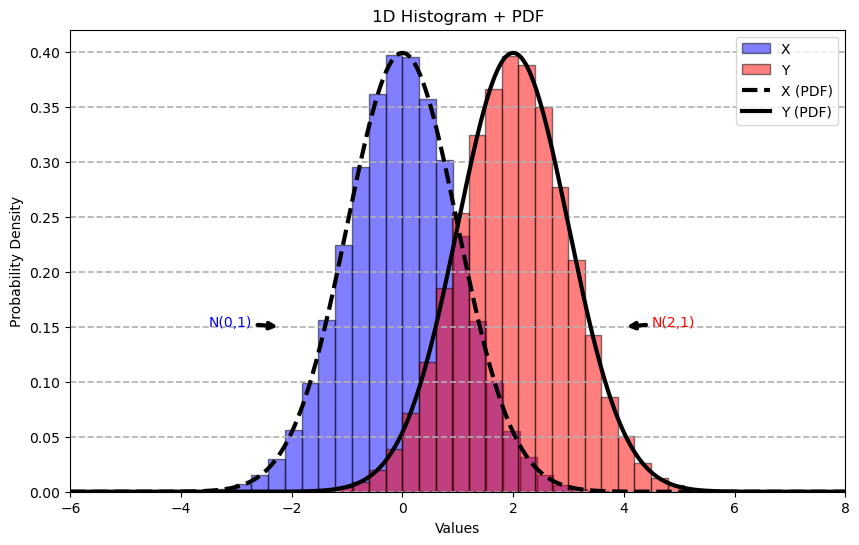

In [54]:
import matplotlib.pyplot as plt 
import numpy as np
from scipy.stats import norm

np.random.seed(0)                   # Fixes random number generator

X = np.random.normal(0,1,100000)
Y = np.random.normal(2,1,100000)

plt.figure(figsize=(10,6))          # Width 10 inches, height 6 inches

plt.hist(X, bins=30, density=True, alpha=0.5, color='blue', edgecolor ='black', label='X')  # Bins : split data into 30 intervals
plt.hist(Y, bins=30, density=True, alpha=0.5, color='red', edgecolor ='black', label='Y')   # Alpha : Transparency (0 to 1)

x_vals = np.linspace(-6, 8, 1000)  # 1000 evenly spaced points between -6 and 8

plt.plot(x_vals, norm.pdf(x_vals, 0, 1), 'k--', linewidth=3, label='X (PDF)')
plt.plot(x_vals, norm.pdf(x_vals, 2, 1), 'k-', linewidth=3, label='Y (PDF)')

plt.annotate('N(0,1)', color='blue', xy=(-2.2,0.15), xytext=(-3.5,0.15), arrowprops=dict(arrowstyle='->', linewidth=3))
plt.annotate('N(2,1)', color='red', xy=(4,0.15), xytext=(4.5,0.15), arrowprops=dict(arrowstyle='->', linewidth=3))

plt.grid(axis="y", linestyle='--', linewidth=1.2)

plt.xlabel("Values")
plt.ylabel("Probability Density")
plt.title("1D Histogram + PDF")
plt.legend()
plt.xlim(-6,8)
plt.ylim(0,0.42)

plt.show()

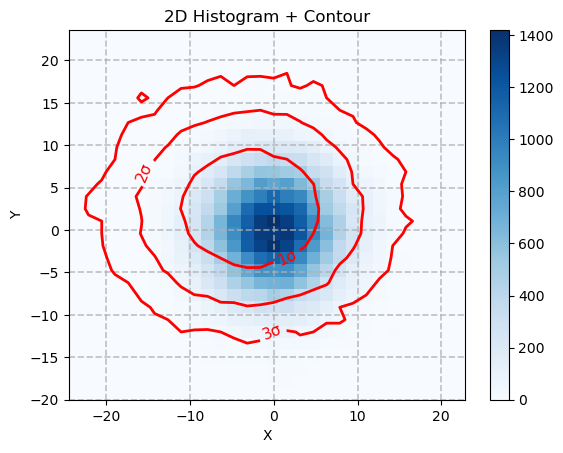

In [63]:
import matplotlib.pyplot as plt 
import numpy as np
from scipy.stats import norm

X2 = np.random.normal(0,5,100000)
Y2 = np.random.normal(0,1,100000)

counts, xedges, yedges, im = plt.hist2d(X2, Y2, bins=30, cmap='Blues') #xedges: bin boundaries

plt.colorbar()

xcenters = 0.5*(xedges[1:] + xedges[:-1])  # Compute bin centers
ycenters = 0.5*(yedges[1:] + yedges[:-1])

Xg, Yg = np.meshgrid(xcenters, ycenters)  # Creates grid

Z = counts / np.sum(counts)  # Converts counts to probability

Z_flat = Z.flatten()     # 2D array into 1D
Z_sorted = np.sort(Z_flat)[::-1]  # Descending order

cumulative = np.cumsum(Z_sorted)

level_1sigma = Z_sorted[np.searchsorted(cumulative, 0.68)]
level_2sigma = Z_sorted[np.searchsorted(cumulative, 0.95)]
level_3sigma = Z_sorted[np.searchsorted(cumulative, 0.997)]

levels = np.sort([level_3sigma, level_2sigma, level_1sigma])  # Contours must be increasing order

contours = plt.contour( Xg, Yg, Z, levels=levels, colors='red', linewidths=2)  # Equal-probability density boundaries

fmt = {level_1sigma: "1σ", level_2sigma: "2σ", level_3sigma: "3σ"}  # Maps contour values to labels

plt.clabel(contours, fmt=fmt, fontsize=11)  # Adds text labels to contour lines
plt.grid(True, linestyle='--', linewidth=1.2, alpha=0.8)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Histogram + Contour")

plt.show()